In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('logistics_2000_dataset.csv')
df.head()

,latitude,longitude,distance_km,demand,accessibility
0,26.804834,80.864214,9.883383,42,0.091883
1,27.012257,80.858912,20.175776,21,0.047224
2,26.933518,81.096252,17.222248,37,0.054878
3,26.885517,80.859837,9.776628,27,0.092793
4,26.726167,80.867902,16.000369,29,0.058822


In [ ]:
# X=df[['latitude','longitude','distance_km','demand','accessibility']]
X=df[['distance_km']]
print(X)

      distance_km
0        9.883383
1       20.175776
2       17.222248
3        9.776628
4       16.000369
...           ...
1995     6.614249
1996    19.210063
1997    17.661289
1998    17.763436
1999    14.912804

[2000 rows x 1 columns]


In [ ]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

[1999.9999999999995, 619.8281557930496, 315.5785734235826, 177.29229401382213, 117.6537366287073, 85.03678993590705, 61.80161994666343, 47.72503116958843, 39.22820539616216, 31.881658704387128, 24.54066839196451, 21.678333322419515, 19.032618715491576, 15.655692862584537]


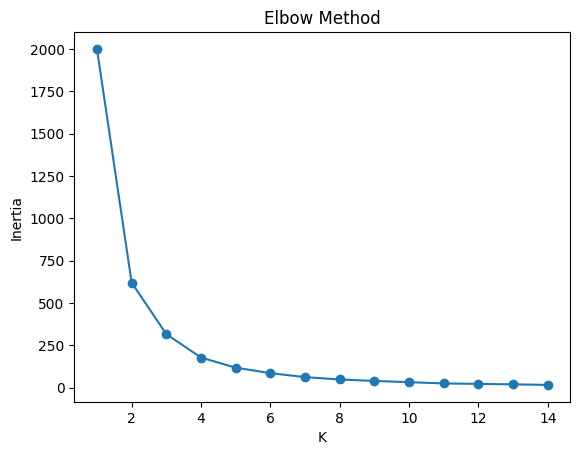

In [ ]:
inertia=[]
for k in range(1,15):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
print(inertia)
plt.plot(range(1,15),inertia,marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [ ]:
kmeans=KMeans(n_clusters=4,random_state=42)
df['cluster']=kmeans.fit_predict(X_scaled)
centers=kmeans.cluster_centers_
centers_original=scaler.inverse_transform(centers)
print(centers_original)

[[ 5.48204074]
 [21.17818506]
 [16.26329534]
 [11.19896831]]


IndexError: index 1 is out of bounds for axis 1 with size 1

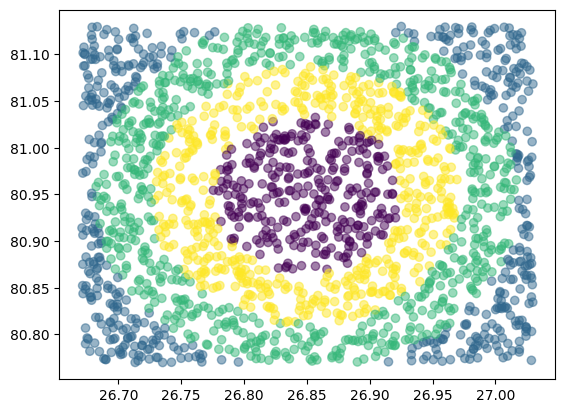

In [ ]:
plt.scatter(df['latitude'],df['longitude'],c=df['cluster'],cmap='viridis',alpha=0.5)
plt.scatter(centers_original[:,0],centers_original[:,1],c='red',marker='X',s=300)
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.title('K-Means Clustering Results')
plt.show()

In [ ]:
summary = df.groupby('cluster').agg({
    'distance_km': 'mean',
    'demand': 'mean',
    'accessibility': 'mean'
})
print(summary)

         distance_km     demand  accessibility
cluster                                       
0           6.408866  24.007481       0.158085
1          17.060348  24.517928       0.057681
2          15.936221  25.507874       0.062170
3          16.932520  25.794567       0.058872
